In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
import seaborn as sns
import scipy
import sklearn
from sklearn.svm import SVC
from scipy.stats import pearsonr
from sklearn import datasets, linear_model
from sklearn import preprocessing
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score,  RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report, confusion_matrix
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor, plot_tree, DecisionTreeClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from scipy.stats import loguniform

#!pip install xlrd 
#!pip install category_encoders
import category_encoders as ce

In [3]:
df = pd.read_excel("TrainDataset2025.xls")
df.head()

,ID,pCR (outcome),RelapseFreeSurvival (outcome),Age,ER,PgR,HER2,TrippleNegative,ChemoGrade,Proliferation,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,TRG002174,1,144.0,41.0,0,0,0,1,3,3,...,0.517172,0.375126,3.325332,0.002314,3880771.500,473.464852,0.000768,0.182615,0.030508,0.000758
1,TRG002178,0,142.0,39.0,1,1,0,0,3,3,...,0.444391,0.444391,3.032144,0.005612,2372009.744,59.459710,0.004383,0.032012,0.001006,0.003685
2,TRG002204,1,135.0,31.0,0,0,0,1,2,1,...,0.534549,0.534549,2.485848,0.006752,1540027.421,33.935384,0.007584,0.024062,0.000529,0.006447
3,TRG002206,0,12.0,35.0,0,0,0,1,3,3,...,0.506185,0.506185,2.606255,0.003755,6936740.794,46.859265,0.005424,0.013707,0.000178,0.004543
4,TRG002210,0,109.0,61.0,1,0,0,0,2,1,...,0.462282,0.462282,2.809279,0.006521,1265399.054,39.621023,0.006585,0.034148,0.001083,0.005626


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Columns: 121 entries, ID to original_ngtdm_Strength
dtypes: float64(108), int64(12), object(1)
memory usage: 378.3+ KB


,pCR (outcome),RelapseFreeSurvival (outcome),Age,ER,PgR,HER2,TrippleNegative,ChemoGrade,Proliferation,HistologyType,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000,...,4.000000e+02,4.000000e+02,4.000000e+02,400.000000,4.000000e+02,400.000000,400.000000,400.000000,400.000000,400.000000
mean,12.697500,56.000208,51.804674,0.547500,2.902500,2.797500,2.830000,9.875000,6.562500,8.63250,...,3.957637e-01,3.911005e-01,2.722189e+00,0.003347,5.679717e+07,178.311246,32500.032620,0.056935,0.005965,0.029322
std,111.107417,27.137584,10.948522,0.498362,49.932114,49.937068,49.935558,86.092911,70.444284,86.20034,...,1.666319e-01,1.615922e-01,7.648849e-01,0.002419,7.063846e+08,1045.453432,177545.921568,0.047179,0.008379,0.115915
min,0.000000,0.000000,23.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.00000,...,7.050000e-11,7.050000e-11,-3.200000e-16,0.000008,0.000000e+00,0.000000,0.000248,0.000000,0.000000,0.000000
25%,0.000000,38.000000,44.516769,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.00000,...,3.199017e-01,3.184398e-01,2.340783e+00,0.001389,1.030473e+06,18.760570,0.001826,0.018628,0.000310,0.001464
50%,0.000000,55.000000,51.019507,1.000000,0.000000,0.000000,0.000000,2.000000,1.000000,1.00000,...,4.095627e-01,4.054695e-01,2.814884e+00,0.002944,3.277334e+06,67.929659,0.004383,0.047740,0.002330,0.003276
75%,0.000000,73.000000,60.000000,1.000000,1.000000,1.000000,1.000000,3.000000,2.000000,1.00000,...,5.000049e-01,4.956920e-01,3.304411e+00,0.004798,9.079686e+06,157.370294,0.013769,0.085321,0.007962,0.009479
max,999.000000,144.000000,79.603012,1.000000,999.000000,999.000000,999.000000,999.000000,999.000000,999.00000,...,8.773779e-01,8.571429e-01,4.947427e+00,0.011301,1.390001e+10,20764.693790,1000000.000000,0.285100,0.060742,1.145601


In [5]:
df.replace(999, pd.NA, inplace=True)


In [6]:
missing_cols = df.isna().sum()
missing_cols = missing_cols[missing_cols > 0]
missing_cols

pCR (outcome)       5
PgR                 1
HER2                1
TrippleNegative     1
ChemoGrade          3
Proliferation       2
HistologyType       3
LNStatus            1
Gene               88
dtype: int64

In [8]:
for col in df.columns:
    print(col, df[col].nunique())

ID 400
pCR (outcome) 2
RelapseFreeSurvival (outcome) 144
Age 321
ER 2
PgR 2
HER2 2
TrippleNegative 2
ChemoGrade 3
Proliferation 3
HistologyType 2
LNStatus 2
TumourStage 4
Gene 2
original_shape_Elongation 400
original_shape_Flatness 400
original_shape_LeastAxisLength 400
original_shape_MajorAxisLength 400
original_shape_Maximum2DDiameterColumn 332
original_shape_Maximum2DDiameterRow 326
original_shape_Maximum2DDiameterSlice 334
original_shape_Maximum3DDiameter 374
original_shape_MeshVolume 400
original_shape_MinorAxisLength 400
original_shape_Sphericity 400
original_shape_SurfaceArea 400
original_shape_SurfaceVolumeRatio 400
original_shape_VoxelVolume 397
original_firstorder_10Percentile 400
original_firstorder_90Percentile 400
original_firstorder_Energy 400
original_firstorder_Entropy 388
original_firstorder_InterquartileRange 400
original_firstorder_Kurtosis 400
original_firstorder_Maximum 400
original_firstorder_MeanAbsoluteDeviation 400
original_firstorder_Mean 400
original_firstord

In [9]:
# Get columns with missing values
missing_cols = df.columns[df.isna().any()]

# Missing data summary
summary = pd.DataFrame({
    'Column': missing_cols,
    'MissingCount': [df[col].isna().sum() for col in missing_cols],
    'Dtype': [df[col].dtype for col in missing_cols]
})

print(summary)


            Column  MissingCount   Dtype
0    pCR (outcome)             5  object
1              PgR             1  object
2             HER2             1  object
3  TrippleNegative             1  object
4       ChemoGrade             3  object
5    Proliferation             2  object
6    HistologyType             3  object
7         LNStatus             1  object
8             Gene            88  object


In [10]:
df_dropped =  df.dropna(subset=['pCR (outcome)'])
df_dropped = df_dropped.drop("RelapseFreeSurvival (outcome)", axis=1)
df_dropped.shape

(395, 120)

In [11]:
missing_cols = df_dropped.columns[df_dropped.isna().any()]
# Missing data summary
summary = pd.DataFrame({
    'Column': missing_cols,
    'MissingCount': [df_dropped[col].isna().sum() for col in missing_cols],
    'Dtype': [df_dropped[col].dtype for col in missing_cols]
})

print(summary)

            Column  MissingCount   Dtype
0              PgR             1  object
1             HER2             1  object
2  TrippleNegative             1  object
3       ChemoGrade             3  object
4    Proliferation             2  object
5    HistologyType             3  object
6         LNStatus             1  object
7             Gene            85  object


In [12]:
'''
df_imputed = df_dropped.copy()

cat_columns = df_imputed.select_dtypes(include=['object', 'category']).columns

cat_cols_to_encode = cat_columns.drop('pCR (outcome)')
encoder = ce.OrdinalEncoder()
nan_placeholder = "__MISSING__"

# Fill NaNs with the placeholder string
df_imputed[cat_cols_to_encode] = df_imputed[cat_cols_to_encode].fillna(nan_placeholder)
df_imputed[cat_cols_to_encode] = encoder.fit_transform(df_imputed[cat_cols_to_encode])

df_imputed.head()
'''

'\ndf_imputed = df_dropped.copy()\n\ncat_columns = df_imputed.select_dtypes(include=[\'object\', \'category\']).columns\n\ncat_cols_to_encode = cat_columns.drop(\'pCR (outcome)\')\nencoder = ce.OrdinalEncoder()\nnan_placeholder = "__MISSING__"\n\n# Fill NaNs with the placeholder string\ndf_imputed[cat_cols_to_encode] = df_imputed[cat_cols_to_encode].fillna(nan_placeholder)\ndf_imputed[cat_cols_to_encode] = encoder.fit_transform(df_imputed[cat_cols_to_encode])\n\ndf_imputed.head()\n'

In [37]:
# Iterative imputation

df_imputed = df_dropped.copy()

# Select categorical columns
cat_columns = df_imputed.select_dtypes(include=['object', 'category']).columns
cat_cols_to_encode = cat_columns.drop('pCR (outcome)')

encoder = ce.OrdinalEncoder(handle_missing='return_nan') 


# Encode categorical features
df_imputed[cat_cols_to_encode] = encoder.fit_transform(df_imputed[cat_cols_to_encode])


## Imputation with IterativeImputer
# Separate target
y_target = df_imputed['pCR (outcome)']
X_features = df_imputed.drop(columns=['pCR (outcome)'])

# Iterative Imputer
imputer = IterativeImputer(max_iter=20, random_state=42)
X_imputed = imputer.fit_transform(X_features)

# Convert back to DataFrame
X_imputed_df = pd.DataFrame(X_imputed,
                            columns=X_features.columns,
                            index=X_features.index)

# Round encoded categorical columns back to integers
for col in cat_cols_to_encode:
    max_val = df_imputed[col].max()
    min_val = df_imputed[col].min()
    X_imputed_df[col] = X_imputed_df[col].clip(lower=min_val, upper=max_val)
    X_imputed_df[col] = X_imputed_df[col].round().astype(int)

    
# Inverse transform encoded categorical columns
X_imputed_df[cat_cols_to_encode] = encoder.inverse_transform(X_imputed_df[cat_cols_to_encode])


# Recombine target
final_df = pd.concat([X_imputed_df, y_target], axis=1)
final_df = final_df[sorted(final_df.columns)]
print("\n--- Missing Value Check ---")
print(final_df.isna().sum())



--- Missing Value Check ---
Age                                  0
ChemoGrade                           0
ER                                   0
Gene                                 0
HER2                                 0
                                    ..
original_shape_Sphericity            0
original_shape_SurfaceArea           0
original_shape_SurfaceVolumeRatio    0
original_shape_VoxelVolume           0
pCR (outcome)                        0
Length: 120, dtype: int64


In [15]:
# Read example test data
test_df = pd.read_excel("TestDatasetExample.xls")
test_df = test_df[sorted(test_df.columns)]
test_df

,Age,ChemoGrade,ER,Gene,HER2,HistologyType,ID,LNStatus,PgR,Proliferation,...,original_shape_Maximum2DDiameterColumn,original_shape_Maximum2DDiameterRow,original_shape_Maximum2DDiameterSlice,original_shape_Maximum3DDiameter,original_shape_MeshVolume,original_shape_MinorAxisLength,original_shape_Sphericity,original_shape_SurfaceArea,original_shape_SurfaceVolumeRatio,original_shape_VoxelVolume
0,56.881588,3,0,0,0,999,TRG002728,0,0,3,...,35.902646,27.294688,37.483330,38.131352,7764.833333,21.339254,0.669515,2832.340764,0.364765,7804
1,60.000000,2,0,999,1,1,TRG002649,0,0,1,...,32.202484,33.301652,28.792360,37.589892,3114.666667,24.695743,0.491559,2098.212173,0.673655,3171
2,58.234086,3,0,1,0,1,TRG002628,1,0,3,...,65.306967,37.107951,52.611786,66.460515,14679.750000,34.722043,0.519888,5576.825046,0.379899,14757


In [16]:
#print(test_df.head())
test_X = test_df.drop(["ID"], axis=1)
test_X.info()
test_pred = pipe.predict(test_X)
print(test_pred)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Columns: 118 entries, Age to original_shape_VoxelVolume
dtypes: float64(107), int64(11)
memory usage: 2.9 KB


In [18]:
final_df.select_dtypes(include=['object', 'category']).columns

Index(['ChemoGrade', 'Gene', 'HER2', 'HistologyType', 'ID', 'LNStatus', 'PgR',
       'Proliferation', 'TrippleNegative', 'pCR (outcome)'],
      dtype='object')

In [34]:
X = final_df.drop(["pCR (outcome)", "ID"], axis=1)
y = final_df["pCR (outcome)"].astype(int)

# Separate numeric and categorical columns
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns

from sklearn.compose import ColumnTransformer
# Scale numeric features and encode categorical features using one-hot encoding
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None), cat_features)
    ]
)


In [20]:
# Initial testing pipeline
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(solver="lbfgs", max_iter=1000))
])

# CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=35)
cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy: %.3f ± %.3f" % (cv_scores.mean(), cv_scores.std()))

# Train/test split for final test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

print("Test Accuracy: %.3f" % accuracy_score(y_test, y_pred))


Cross-validation scores: [0.74683544 0.81012658 0.74683544 0.82278481 0.74683544]
Mean CV accuracy: 0.775 ± 0.034
Test Accuracy: 0.824


In [23]:
log_model = LogisticRegression()
log_model.fit(X_train,y_train)
y_pred = log_model.predict(X_test)
model_accuracy  = accuracy_score(y_pred,y_test)
print("The Accuracy of simple logistic regression without hyperparmeter:",model_accuracy)

The Accuracy of simple logistic regression without hyperparmeter: 0.7899159663865546


C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [38]:
# Grid search for bests columns
param_grid = [
    {'penalty':['l1','l2','elasticnet','none'],
     'C' : np.logspace(-4,4,20),
     'solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
     'max_iter'  : [100,1000,2500,5000],
     "class_weight": [None, "balanced"]
    }
]

from sklearn.model_selection import GridSearchCV
clf = GridSearchCV(log_model,param_grid = param_grid, cv = cv, verbose=False,n_jobs=-1)
clf

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(C=2.782559402207126, max_iter=5000),
             n_jobs=-1,
             param_grid=[{'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                          'class_weight': [None, 'balanced'],
                          'max_iter': [100, 1000, 2500, 5000],
                          'penalty': ['l1', 'l2', 'elasticnet', 'none'],
                          'solver': ['lbfgs', 'newton-cg', 'liblinear', 'sag',
                                     'saga']}],
             verbose=False)

In [33]:
best_clf = clf.fit(X,y)
best_clf.best_estimator_

C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
160 fits failed out of a total of 3760.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
85 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\Alonso\anaconda3\Lib\site-p

C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=166.81005372000558, max_iter=5000)

In [39]:
print(f'Accuracy: {best_clf.score(X,y):.3f}')

Accuracy: 0.797


In [24]:
param_grid = [

    # 1) L2 regularisation with solvers that support it
    {
        "penalty": ["l2"],
        "solver": ["lbfgs", "newton-cg", "sag", "saga"],
        "C": np.logspace(-4, 4, 10),
        "max_iter": [100, 1000, 2500, 5000],
        "class_weight": [
            None,
            "balanced"
        ],
    },

    # 2) L1 regularisation (only liblinear and saga support it)
    {
        "penalty": ["l1"],
        "solver": ["liblinear", "saga"],
        "C": np.logspace(-4, 4, 10),
        "max_iter": [100, 1000, 2500, 5000],
        "class_weight": [
            None,
            "balanced"
        ],
    },

    # 3) Elastic net (only saga supports it, needs l1_ratio)
    {
        "penalty": ["elasticnet"],
        "solver": ["saga"],
        "l1_ratio": [0.1, 0.5, 0.9],
        "C": np.logspace(-4, 4, 10),
        "max_iter": [100, 1000, 2500, 5000],
        "class_weight": [
            None,
            "balanced"
        ],
    },

    # 4) No regularisation (penalty="none")
    {
        "penalty": ["none"],
        "solver": ["lbfgs", "newton-cg", "sag", "saga"],
        "max_iter": [100, 1000, 2500, 5000],
        "class_weight": [
            None,
            "balanced"
        ],
    },
]

from sklearn.model_selection import GridSearchCV
clf = GridSearchCV(log_model,param_grid = param_grid, cv = cv, verbose=0,n_jobs=-1)
best_clf = clf.fit(X,y)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=35, shuffle=True),
             estimator=LogisticRegression(), n_jobs=-1,
             param_grid=[{'C': array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                          'class_weight': [None, 'balanced'],
                          'max_iter': [100, 1000, 2500, 5...
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04]),
                          'class_weight': [None, 'balanced'],
                          'l1_ratio': [0.1, 0.5, 0.9],
                          'max_iter': [100, 1000, 2500, 5000],
                          'penalty': ['elasticnet'], 'solver': ['saga']},
                         {'class_weight': [None, 'balanced'],
                          'max_iter': [100, 1000, 2500, 5000],
                          'penalty': ['none'],
                          'solver': ['lbfgs', 'newton-cg', 'sag', 'saga']}])

C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
160 fits failed out of a total of 3760.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
78 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\base.py", line 1382, in wrapper
    estimator._validate_params()
  File "C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "C:\Users\Alonso\anaconda3\Lib\site-p

C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [26]:
best_clf.best_estimator_

LogisticRegression(C=166.81005372000558, max_iter=5000)

In [36]:
# Logistic Regression
log_model = LogisticRegression(max_iter=5000, solver='lbfgs', penalty='l2', tol=0.0001, 
                               C=np.float64(2.782559402207126))

# Pipeline = scaling + logistic regression
pipe = Pipeline([
    ("preprocess", preprocessor),
    ("clf", log_model)
])

# K-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy: %.3f ± %.3f" % (cv_scores.mean(), cv_scores.std()))

Cross-validation scores: [0.73417722 0.81012658 0.7721519  0.75949367 0.72151899]
Mean CV accuracy: 0.759 ± 0.031


In [47]:
# SVM start
X = final_df.drop(["pCR (outcome)", "ID"], axis=1)
y = final_df["pCR (outcome)"].astype(int)

# Separate numeric and categorical columns
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop=None), cat_features)
    ]
)

# Full pipeline: preprocessing + SVM
svm_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("svm", SVC(kernel="rbf"))
])

In [52]:
# Repeated stratified CV (more stable on small data)
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

param_dist = {
    "svm__C": loguniform(1e-3, 1e3),
    "svm__gamma": loguniform(1e-4, 1e1),
    "svm__class_weight": [None, "balanced"],
}

search = RandomizedSearchCV(
    estimator=svm_pipe,
    param_distributions=param_dist,
    n_iter=50,                  # small dataset → can afford a decent search
    cv=cv,
    scoring="roc_auc",          # or "f1", "balanced_accuracy"
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X, y)

print("Best params:", search.best_params_)
print("Best CV score (ROC AUC):", search.best_score_)

best_svm = search.best_estimator_


Fitting 25 folds for each of 50 candidates, totalling 1250 fits
Best params: {'svm__C': 70.85721663941601, 'svm__class_weight': None, 'svm__gamma': 0.00012017974027309969}
Best CV score (ROC AUC): 0.6905115056775398


In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

best_svm.fit(X_train, y_train)
y_pred = best_svm.predict(X_test)
y_proba = best_svm.decision_function(X_test)  # for ROC AUC

print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification report:\n", classification_report(y_test, y_pred))


Test accuracy: 0.7899159663865546
Test ROC AUC: 0.7459574468085106
Confusion matrix:
 [[94  0]
 [25  0]]
Classification report:
               precision    recall  f1-score   support

           0       0.79      1.00      0.88        94
           1       0.00      0.00      0.00        25

    accuracy                           0.79       119
   macro avg       0.39      0.50      0.44       119
weighted avg       0.62      0.79      0.70       119



C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  The class to report if `average='binary'` and the data is binary,
C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  The class to report if `average='binary'` and the data is binary,
C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  The class to report if `average='binary'` and the data is binary,


In [41]:
# SVM
# Split dataset into testing and training
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
# Perform feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Run the model
Svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
Svm_model.fit(X_train_scaled, y_train)
y_pred = Svm_model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7899159663865546


In [74]:
##Random Forest

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=6,
    min_samples_leaf=4,
    class_weight='balanced_subsample',
    random_state=42
)
# Fit Random Forest
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluate
print("\nRandom Forest Results:")
print("Test Accuracy: %.3f" % accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))



Random Forest Results:
Test Accuracy: 0.756
Confusion Matrix:
 [[87  7]
 [22  3]]
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.93      0.86        94
           1       0.30      0.12      0.17        25

    accuracy                           0.76       119
   macro avg       0.55      0.52      0.51       119
weighted avg       0.69      0.76      0.71       119



In [35]:


# K-Fold Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(Svm_model, X, y, cv=kf, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Mean CV accuracy:", np.mean(scores))



Cross-validation scores: [0.79746835 0.78481013 0.69620253 0.81012658 0.84810127]
Mean CV accuracy: 0.7873417721518987


In [46]:
#print(final_df.dtypes.to_dict())


In [57]:
# Count samples per class
class_counts = final_df["pCR (outcome)"].value_counts()
print(class_counts)
# Total samples
total_samples = len(final_df)

# Pick a specific class, e.g. class '1'
specific_class = 1
count_specific = class_counts[specific_class]

# Calculate imbalance ratio (relative to dataset)
imbalance_ratio = count_specific / total_samples
print(f"Class {specific_class} ratio: {imbalance_ratio:.3f}")

# Or compare minority vs majority
majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()
imbalance_ratio = class_counts[minority_class] / class_counts[majority_class]
print(f"Minority/Majority ratio: {imbalance_ratio:.3f}")


pCR (outcome)
0    311
1     84
Name: count, dtype: int64
Class 1 ratio: 0.213
Minority/Majority ratio: 0.270


In [58]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    roc_curve
)

# -----------------------------
# Build X, y
# -----------------------------
y = final_df["pCR (outcome)"].astype(int)
X = final_df.drop(["pCR (outcome)", "ID"], axis=1)

num_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Number of numeric features:", len(num_features))
print("Categorical features:", cat_features)

# Train / test split (hold out 30% for final evaluation)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)


Number of numeric features: 110
Categorical features: ['ChemoGrade', 'Gene', 'HER2', 'HistologyType', 'LNStatus', 'PgR', 'Proliferation', 'TrippleNegative']


In [59]:
# Preprocessing and Feature Selection

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Preprocess: scale numeric, one-hot encode categoricals
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ]
)

# Random Forest used as feature selector
rf_selector = SelectFromModel(
    RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        n_jobs=-1,
        random_state=42,
        class_weight="balanced"  # helps with pCR imbalance
    ),
    threshold="median"   # keep features with importance above median, can also try mean
)


In [60]:
# SVM Pipeline and Hyperparameter Search
from scipy.stats import loguniform
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV

# Full pipeline: preprocessing -> RF feature selection -> SVM
svm_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("select", rf_selector),
    ("svm", SVC(kernel="rbf", probability=False))
])

# Repeated stratified CV – good for small, imbalanced datasets
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

# Hyperparameter search space
param_dist = {
    "svm__C": loguniform(1e-3, 1e3),
    "svm__gamma": loguniform(1e-4, 1e1),
    "svm__class_weight": [None, "balanced"],
}

search = RandomizedSearchCV(
    estimator=svm_pipe,
    param_distributions=param_dist,
    n_iter=50,              # can increase if compute allows
    cv=cv,
    scoring="roc_auc",      # key metric for this task
    n_jobs=-1,
    random_state=42,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV ROC AUC:", search.best_score_)

best_svm = search.best_estimator_
comments = 
'''
Do the best C and gamma sit near the edges of your search range?
If yes, extend the range (e.g. 1e-4 to 1e4).
'''

Fitting 25 folds for each of 50 candidates, totalling 1250 fits
Best params: {'svm__C': 0.1767016940294795, 'svm__class_weight': None, 'svm__gamma': 0.0008263688714158015}
Best CV ROC AUC: 0.6634699532321097


In [61]:
# Evaluation of Model
# Fit best pipeline on full training set
best_svm.fit(X_train, y_train)

# Decision scores on test set
scores_test = best_svm.decision_function(X_test)  # continuous margins
y_pred_default = best_svm.predict(X_test)

# Basic metrics with default decision threshold
roc_auc = roc_auc_score(y_test, scores_test)
pr_auc = average_precision_score(y_test, scores_test)  # PR AUC
bal_acc = balanced_accuracy_score(y_test, y_pred_default)

print("Test ROC AUC:", roc_auc)
print("Test PR AUC:", pr_auc)
print("Test balanced accuracy:", bal_acc)
print("Confusion matrix (default threshold):\n", confusion_matrix(y_test, y_pred_default))
print("Classification report (default threshold):\n", classification_report(y_test, y_pred_default))


Test ROC AUC: 0.7076595744680851
Test PR AUC: 0.4403699166183665
Test balanced accuracy: 0.5
Confusion matrix (default threshold):
 [[94  0]
 [25  0]]
Classification report (default threshold):
               precision    recall  f1-score   support

           0       0.79      1.00      0.88        94
           1       0.00      0.00      0.00        25

    accuracy                           0.79       119
   macro avg       0.39      0.50      0.44       119
weighted avg       0.62      0.79      0.70       119



C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  The class to report if `average='binary'` and the data is binary,
C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  The class to report if `average='binary'` and the data is binary,
C:\Users\Alonso\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  The class to report if `average='binary'` and the data is binary,


Best threshold by balanced accuracy: -1.0004337051142753
Balanced accuracy at this threshold: 0.6685106382978723
Sensitivity (recall for pCR=1): 0.72
Specificity: 0.6170212765957447
Confusion matrix (best threshold):
 [[58 36]
 [ 7 18]]
Classification report (best threshold):
               precision    recall  f1-score   support

           0       0.89      0.62      0.73        94
           1       0.33      0.72      0.46        25

    accuracy                           0.64       119
   macro avg       0.61      0.67      0.59       119
weighted avg       0.77      0.64      0.67       119



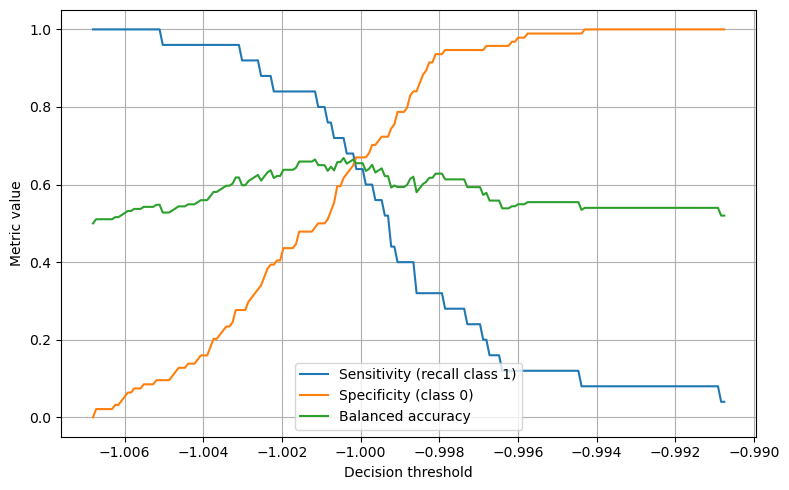

In [62]:
# Threshold tuning
import matplotlib.pyplot as plt

# Compute ROC and PR curves
fpr, tpr, roc_thresholds = roc_curve(y_test, scores_test)
prec, rec, pr_thresholds = precision_recall_curve(y_test, scores_test)

# Example: try a grid of thresholds and compute metrics
thresholds = np.linspace(scores_test.min(), scores_test.max(), 200)

results = []
for thr in thresholds:
    y_pred_thr = (scores_test >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thr).ravel()
    
    # Avoid division by zero
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0  # recall for pCR=1
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0  # specificity
    bal_acc_thr = 0.5 * (sens + spec)
    
    results.append((thr, sens, spec, bal_acc_thr))

thr_arr = np.array([r[0] for r in results])
sens_arr = np.array([r[1] for r in results])
spec_arr = np.array([r[2] for r in results])
bal_arr  = np.array([r[3] for r in results])

# Example: pick the threshold that maximises balanced accuracy
best_idx = np.argmax(bal_arr)
best_thr = thr_arr[best_idx]
print("Best threshold by balanced accuracy:", best_thr)
print("Balanced accuracy at this threshold:", bal_arr[best_idx])
print("Sensitivity (recall for pCR=1):", sens_arr[best_idx])
print("Specificity:", spec_arr[best_idx])

# Predictions with best threshold
y_pred_best = (scores_test >= best_thr).astype(int)
print("Confusion matrix (best threshold):\n", confusion_matrix(y_test, y_pred_best))
print("Classification report (best threshold):\n", classification_report(y_test, y_pred_best))

# Optional: visualise sensitivity and specificity vs threshold
plt.figure(figsize=(8, 5))
plt.plot(thr_arr, sens_arr, label="Sensitivity (recall class 1)")
plt.plot(thr_arr, spec_arr, label="Specificity (class 0)")
plt.plot(thr_arr, bal_arr, label="Balanced accuracy")
plt.xlabel("Decision threshold")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
comment = 
''''''
How many features survive the selector: rf_selector.estimator_.feature_importances_ and rf_selector.get_support().sum().
'''